--- 
## Analyse Descriptive Univariée (Graphiques Utiles pour Rapport Finale)

In [71]:
import pandas as pd
df = pd.read_excel("Base_ER_FR.xlsx")

In [2]:
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_EAD', 'E_OFF', 'E_ONB', 'MREVAU', 'MREVNU', 'MREVTOT', 'MTECH',
       'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'Unnamed: 19'],
      dtype='str')

In [3]:
df = df.drop(columns=["Unnamed: 19"])

VARIABLE ID : identifiant unique associe a chaque observation

VARIABLE AGE_CLI : age du client

In [4]:
df["AGE_CLI"].describe(percentiles=[0.25, 0.5, 0.75])

count    99524.000000
mean        51.958472
std         14.941231
min         18.000000
25%         40.000000
50%         52.000000
75%         64.000000
max         92.000000
Name: AGE_CLI, dtype: float64

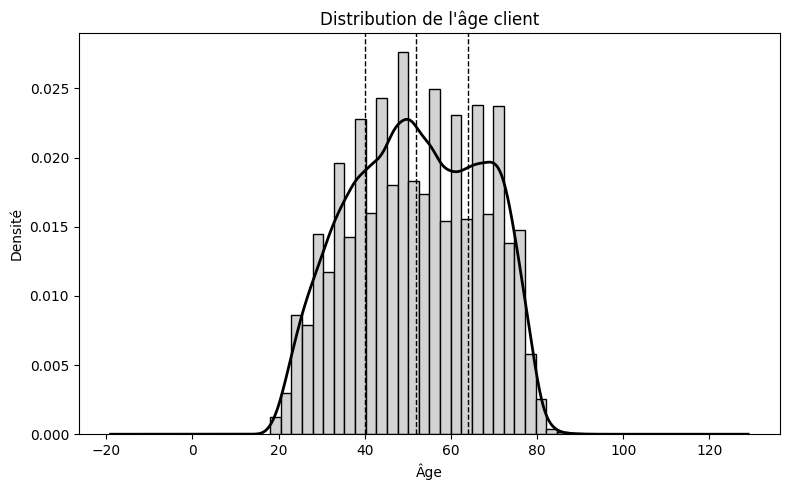

In [5]:
import matplotlib.pyplot as plt
import numpy as np

age = df["AGE_CLI"].dropna()

# quartiles
q25, q50, q75 = np.percentile(age, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(age, bins=30, density=True, color="lightgrey", edgecolor="black")

age.plot(kind="density", color="black", linewidth=2)
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de l'âge client")
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()


In [6]:
print(
    f"L'âge des clients est compris entre {int(age.min())} et {int(age.max())} ans. "
    f"La distribution est centrée autour de {int(q50)} ans, avec des premier et "
    f"troisième quartiles respectivement égaux à {int(q25)} et {int(q75)} ans. "
)


L'âge des clients est compris entre 18 et 92 ans. La distribution est centrée autour de 52 ans, avec des premier et troisième quartiles respectivement égaux à 40 et 64 ans. 


VARIABLE B_MAT : maturite initiale du credit, exprimee en mois

In [7]:
df["B_MAT"].describe(percentiles=[0.25, 0.5, 0.75])

count    98620.000000
mean        70.807585
std         43.506068
min          0.000000
25%         48.000000
50%         61.000000
75%         78.250000
max        300.000000
Name: B_MAT, dtype: float64

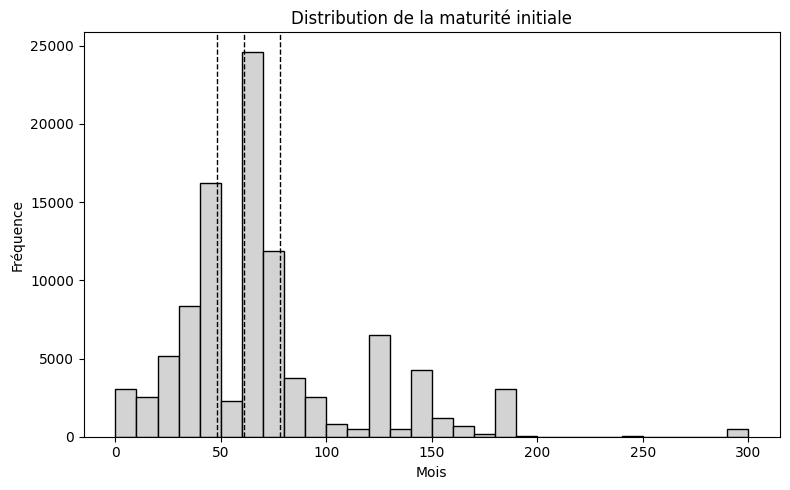

In [8]:
bmat = df["B_MAT"].dropna()
q25, q50, q75 = np.percentile(bmat, [25, 50, 75])


plt.figure(figsize=(8, 5))
plt.hist(bmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de la maturité initiale")
plt.xlabel("Mois")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

VARIABLE B_RESMAT : maturite residuelle du credit (duree restante jusqu’a l’echeance d’un
credit), exprimee en mois

In [9]:
df["B_RESMAT"].describe(percentiles=[0.25, 0.5, 0.75])

count    98620.000000
mean        36.449990
std         37.721117
min          0.000000
25%          7.000000
50%         27.000000
75%         50.000000
max        298.000000
Name: B_RESMAT, dtype: float64

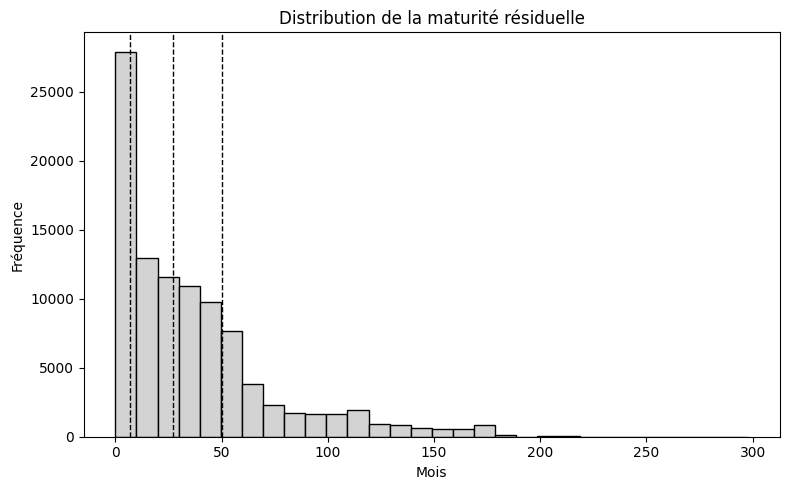

In [10]:
bresmat = df["B_RESMAT"].dropna()
q25, q50, q75 = np.percentile(bresmat, [25, 50, 75])

plt.figure(figsize=(8, 5))
plt.hist(bresmat, bins=30, color="lightgrey", edgecolor="black")
plt.axvline(q25, linestyle="--", color="black", linewidth=1)
plt.axvline(q50, linestyle="--", color="black", linewidth=1)
plt.axvline(q75, linestyle="--", color="black", linewidth=1)
plt.title("Distribution de la maturité résiduelle")
plt.xlabel("Mois")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

VARIABLE CLASSACT : classe d'actif

VARIABLE CSP : catégorie socio profesionnel (regroupement à traiter)

VARIABLE DARRET : date d’arret ou de reference associee au credit.

In [72]:
df["DARRET"] = pd.to_datetime(
    df["DARRET"].astype(str),
    format="%Y%m",
    errors="coerce"
)
df["DARRET"].describe()


count                        100000
mean     2021-03-10 11:32:02.976000
min             2019-01-01 00:00:00
25%             2019-12-01 00:00:00
50%             2021-03-01 00:00:00
75%             2022-05-01 00:00:00
max             2023-12-01 00:00:00
Name: DARRET, dtype: object

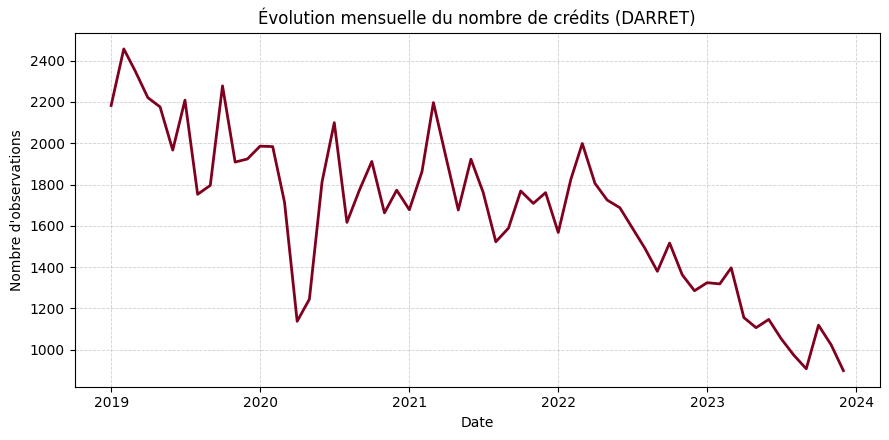

In [74]:
monthly_counts = (
    df
    .groupby(df["DARRET"].dt.to_period("M").dt.to_timestamp())
    .size()
    .reset_index(name="n_obs")
    .rename(columns={"DARRET": "DARRET_M"})
)

plt.figure(figsize=(9, 4.5))

plt.plot(
    monthly_counts["DARRET_M"],
    monthly_counts["n_obs"],
    color="#800020",      # bordeaux
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.title("Évolution mensuelle du nombre de crédits (DARRET)")

plt.grid(
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()
plt.show()


VARIABLE E_EAD :  exposition au defaut du contrat 

In [13]:
df["E_EAD"].describe(percentiles=[0.25, 0.5, 0.75])

count     98620.000000
mean        998.009810
std        5744.202071
min           0.000000
25%           0.000000
50%           0.000000
75%           0.190000
max      267563.810000
Name: E_EAD, dtype: float64

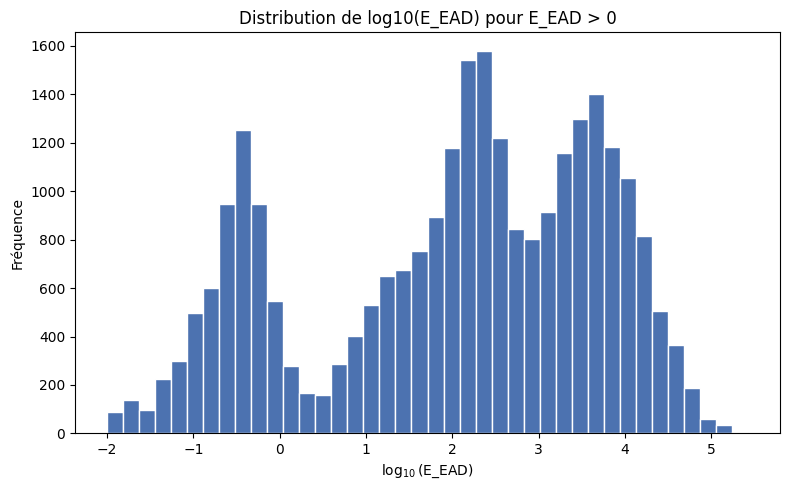

In [14]:
ead1 = df.loc[df["E_EAD"] > 0, "E_EAD"]
logead1 = np.log10(ead1)

plt.figure(figsize=(8, 5))
plt.hist(
    logead1,
    bins=40,
    color="#4C72B0",
    edgecolor="white"
)

plt.xlabel(r"$\log_{10}(\mathrm{E\_EAD})$")
plt.ylabel("Fréquence")
plt.title("Distribution de log10(E_EAD) pour E_EAD > 0")


plt.tight_layout()
plt.show()

VARIABLE E_OFF : exposition hors bilan associee au credit

In [15]:
df["E_OFF"].describe()

count    98620.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: E_OFF, dtype: float64

VARIABLE E_ONB : montant du bilan

In [16]:
(df["E_ONB"].fillna(0) == df["E_EAD"].fillna(0)).all()


np.True_

VARIABLE MREVAU : montant autre revenu client

In [17]:
df["MREVAU"].describe(percentiles=[0.25, 0.5, 0.75])

count     99954.00000
mean         96.15121
std         952.11043
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max      194096.00000
Name: MREVAU, dtype: float64

VARIABLE MREVNU : montant du revenu du client

In [18]:
df["MREVNU"].describe(percentiles=[0.25, 0.5, 0.75])

count     99954.000000
mean       2433.213588
std        2802.421818
min           0.000000
25%        1525.250000
50%        2000.000000
75%        2757.000000
max      265000.000000
Name: MREVNU, dtype: float64

VARIABLE MREVTOT :  montant du revenu total du client

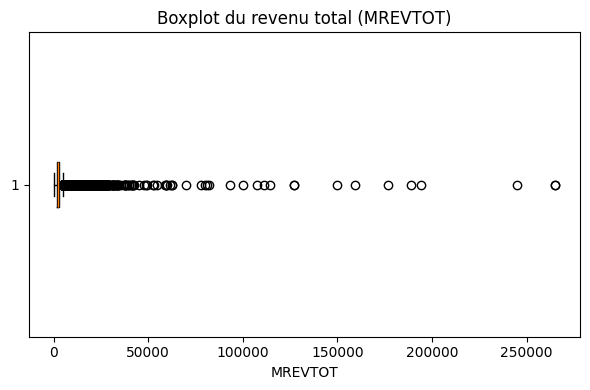

In [19]:
mrevtot = df["MREVTOT"].dropna()
plt.figure(figsize=(6, 4))
plt.boxplot(
    mrevtot,
    vert=False,
    showfliers=True
)
plt.xlabel("MREVTOT")
plt.title("Boxplot du revenu total (MREVTOT)")

plt.tight_layout()
plt.show()

VARIABLE MTECH : montant de l’echeance theorique du credit (le paiement periodique contractuel que le client est cense verser a chaque echeance (mensualite), hors evenement particulier)

In [20]:
df["MTECH"].describe(percentiles=[0.25, 0.5, 0.75])

count    100000.000000
mean        228.889002
std         259.948942
min           0.000000
25%          94.670000
50%         178.685000
75%         296.970000
max       35915.740000
Name: MTECH, dtype: float64

VARIABLE NBIMP :  nombre d’impayes observes sur le credit.

In [21]:
df["NBIMP"].describe(percentiles=[0.25, 0.5, 0.75])

count    100000.000000
mean          0.006100
std           0.125471
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: NBIMP, dtype: float64

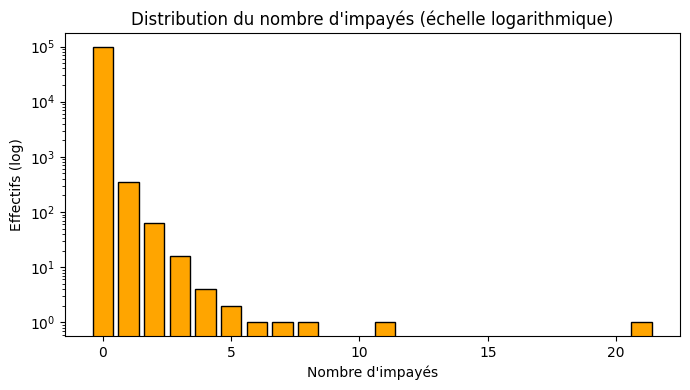

In [22]:
nbimp_counts = df["NBIMP"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(
    nbimp_counts.index,
    nbimp_counts.values,
    color="orange",
    edgecolor="black"
)

plt.yscale("log")
plt.xlabel("Nombre d'impayés")
plt.ylabel("Effectifs (log)")
plt.title("Distribution du nombre d'impayés (échelle logarithmique)")

plt.tight_layout()
plt.show()

VARIABLE NB_ECH : nombre total d’echeances prevues par le contrat.

In [23]:
df["NB_ECH"].describe(percentiles=[0.25, 0.5, 0.75])  

count    100000.000000
mean         62.102200
std          40.731397
min           1.000000
25%          36.000000
50%          60.000000
75%          72.000000
max         300.000000
Name: NB_ECH, dtype: float64

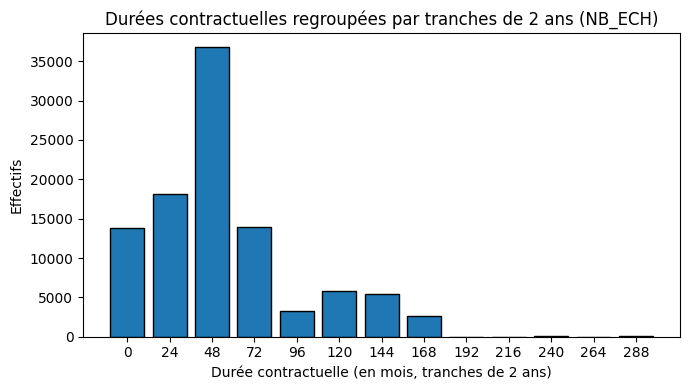

In [24]:
nb_ech_2y_counts = (
    (df["NB_ECH"] // 24 * 24)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))

plt.bar(
    nb_ech_2y_counts.index.astype(str),
    nb_ech_2y_counts.values,
    edgecolor="black"
)

plt.xlabel("Durée contractuelle (en mois, tranches de 2 ans)")
plt.ylabel("Effectifs")
plt.title("Durées contractuelles regroupées par tranches de 2 ans (NB_ECH)")

plt.tight_layout()
plt.show()


VARIABLE produit :  type de produit de credit

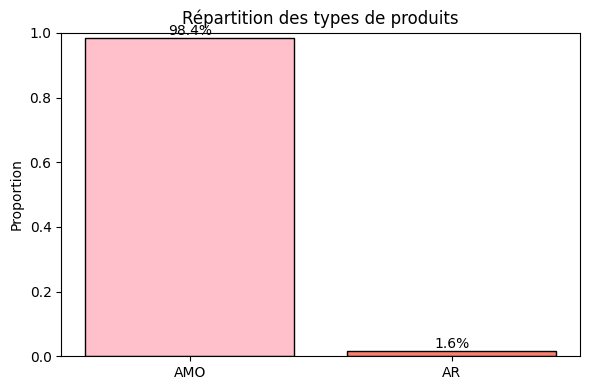

In [25]:
prod_counts = df["produit"].value_counts()
prod_props = prod_counts / prod_counts.sum()


plt.figure(figsize=(6, 4))
bars = plt.bar(
    prod_props.index,
    prod_props.values,
    color=["pink", "salmon"],
    edgecolor="black"
)

plt.ylabel("Proportion")
plt.title("Répartition des types de produits")

for bar, val in zip(bars, prod_props.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f"{val*100:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


VARIABLE RA :  montant du remboursement anticipe observe sur le credit

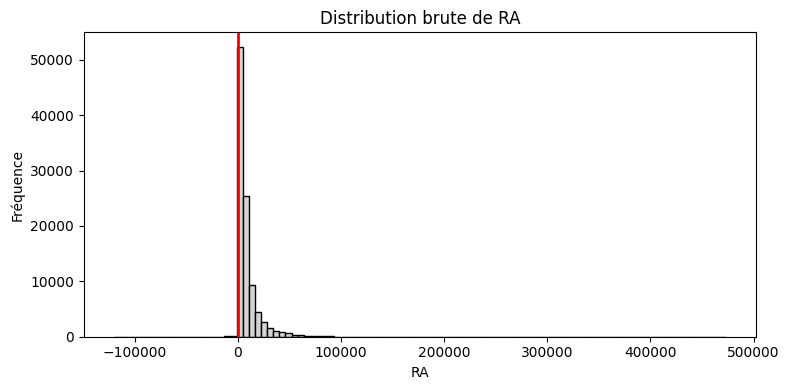

In [26]:
ra = df["RA"].dropna()

plt.figure(figsize=(8, 4))

plt.hist(
    ra,
    bins=100,
    color="lightgrey",
    edgecolor="black"
)

# Ligne verticale en zéro
plt.axvline(0, color="red", linewidth=2)

plt.xlabel("RA")
plt.ylabel("Fréquence")
plt.title("Distribution brute de RA")

plt.tight_layout()
plt.show()

VARIABLE Tx :  correspond au taux d’interet contractuel du credit

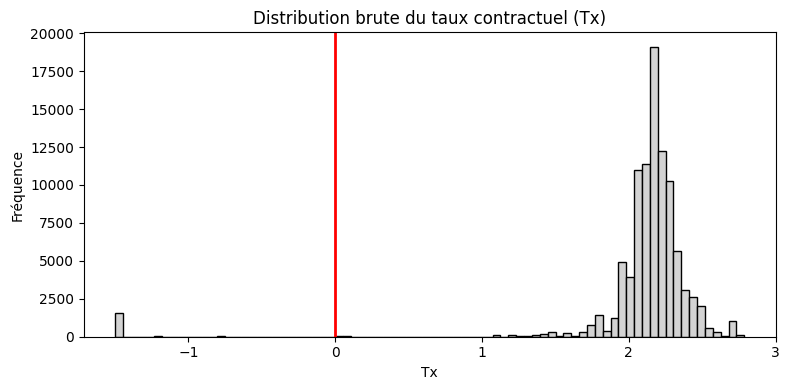

In [27]:
tx = df["Tx"].dropna()

plt.figure(figsize=(8, 4))

plt.hist(
    tx,
    bins=80,
    color="lightgrey",
    edgecolor="black"
)

# Ligne verticale en zéro (taux négatifs)
plt.axvline(0, color="red", linewidth=2)

plt.xlabel("Tx")
plt.ylabel("Fréquence")
plt.title("Distribution brute du taux contractuel (Tx)")

plt.tight_layout()
plt.show()

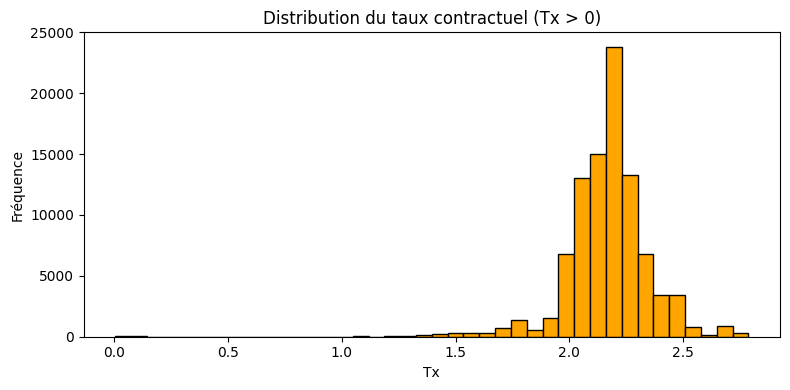

In [28]:
# Restriction aux taux strictement positifs
tx_pos = tx[tx > 0]

plt.figure(figsize=(8, 4))

plt.hist(
    tx_pos,
    bins=40,
    color="orange",
    edgecolor="black"
)

plt.xlabel("Tx")
plt.ylabel("Fréquence")
plt.title("Distribution du taux contractuel (Tx > 0)")

plt.tight_layout()
plt.show()


--- 

## Traitement des valeurs manquantes :

In [29]:
na_table = pd.DataFrame({
    "nb_na": df.isna().sum(),
    "pourcentage_na": df.isna().mean()
}).sort_values("pourcentage_na", ascending=False)

na_table

,nb_na,pourcentage_na
Tx,4886,0.04886
CSP,2478,0.02478
B_MAT,1380,0.01380
E_ONB,1380,0.01380
E_EAD,1380,0.01380
E_OFF,1380,0.01380
B_RESMAT,1380,0.01380
AGE_CLI,476,0.00476
MREVTOT,46,0.00046
MREVNU,46,0.00046


In [30]:
df2 = df.copy()

drop = [
    "ID",          # identifiant technique
    "E_OFF",       # variable dégénérée
    "E_ONB",       # colinéaire parfaite avec E_EAD
    "CLASSACT"     # déséquilibre extrême, non discriminante
]

df2 = df2.drop(columns=drop, errors="ignore")

In [31]:
# Création d'une nouvelle variable sans incohérence de valeurs négatives du remboursement anticipé
df2["RA2"] = df2["RA"].clip(lower=0)

In [32]:
# Imputation de l'âge par la médiane
df2["AGE_CLI"] = df2["AGE_CLI"].fillna(df2["AGE_CLI"].median())

# Ajout d'une catégorie "Inconnu" pour la CSP
df2["CSP"] = df2["CSP"].fillna("Inconnu")

# Incohérences économiques du taux (on garde seulement les taux positifs)
df2["Tx"] = df2["Tx"].where(df2["Tx"] > 0)
# Imputation du taux par la médiane
tx_median = df2["Tx"].median()
df2["Tx"] = df2["Tx"].fillna(tx_median)

# Imputation de la maturité initiale par la médiane
df2["B_MAT"] = df2["B_MAT"].fillna(df2["B_MAT"].median())

# Imputation de la maturité résiduelle par la médiane et correction des valeurs négatives
df2["B_RESMAT"] = df2["B_RESMAT"].fillna(df2["B_RESMAT"].median())
df2.loc[df2["B_RESMAT"] < 0, "B_RESMAT"] = 0

# Imputation de E_EAD par la médiane
df2["E_EAD"] = df2["E_EAD"].fillna(df2["E_EAD"].median())

# Imputation des variables de revenu par la médiane
for v in ["MREVNU", "MREVAU", "MREVTOT"]:
    df2[v] = df2[v].fillna(df2[v].median())


In [33]:
df2.isna().sum().sort_values(ascending=False)


AGE_CLI     0
B_MAT       0
B_RESMAT    0
CSP         0
DARRET      0
E_EAD       0
MREVAU      0
MREVNU      0
MREVTOT     0
MTECH       0
NBIMP       0
NB_ECH      0
produit     0
RA          0
Tx          0
RA2         0
dtype: int64

--- 
## Création de Variables Cohérentes

Regroupement CSP (essaie)

In [34]:
csp_map = {
    # SALARIÉS 
    70.0: "SALARIE",
    52.0: "SALARIE",
    46.0: "SALARIE",
    47.0: "SALARIE",
    48.0: "SALARIE",
    54.0: "SALARIE",
    55.0: "SALARIE",
    56.0: "SALARIE",
    36.0: "SALARIE",
    31.0: "SALARIE",
    32.0: "SALARIE",
    45.0: "SALARIE",
    53.0: "SALARIE",

    # INACTIFS
    60.0: "INACTIF",
    64.0: "INACTIF",

    # INDÉPENDANTS / AUTRES ACTIFS
    42.0: "INDEPENDANT",
    82.0: "INDEPENDANT",
    87.0: "INDEPENDANT",
    23.0: "INDEPENDANT"
}

df2["CSP_grp"] = df2["CSP"].map(csp_map)
df2["CSP_grp"] = df2["CSP_grp"].fillna("AUTRE")


csp_check = (
    df2["CSP_grp"]
    .value_counts(dropna=False)
    .to_frame("effectifs")
)
csp_check["pourcentage"] = 100 * csp_check["effectifs"] / len(df2)
csp_check



,effectifs,pourcentage
CSP_grp,,
SALARIE,78233,78.233
INACTIF,11926,11.926
AUTRE,6137,6.137
INDEPENDANT,3704,3.704


In [35]:
#Création de DARRET_M pour un effet mensuel
df2["DARRET_M"] = df2["DARRET"].dt.to_period("M").astype(str)

#Création de IMP qui indique si le client a eu au moins un impayé
df2["IMP"] = (df2["NBIMP"] > 0).astype(int)

#log de E_EAD pour réduire l'effet des valeurs extrêmes
df2["log_EAD"] = np.log1p(df2["E_EAD"])

#Création d'une variable de ratio d'endettement (DTI proxy)
df2["DTI_proxy"] = df2["MTECH"] / df2["MREVTOT"]

#Spread du taux par rapport à la médiane
tx_ref = df2["Tx"].median()
df2["Tx_spread"] = df2["Tx"] - tx_ref

# Regroupement de NB_ECH en tranches de 2 ans (24 mois) (pas obligé mais on peut tester)
df2["B_RESMAT_2Y"] = (df2["B_RESMAT"] // 24) * 24






In [36]:
df2.columns

Index(['AGE_CLI', 'B_MAT', 'B_RESMAT', 'CSP', 'DARRET', 'E_EAD', 'MREVAU',
       'MREVNU', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'RA2', 'CSP_grp', 'DARRET_M', 'IMP', 'log_EAD', 'DTI_proxy',
       'Tx_spread', 'B_RESMAT_2Y'],
      dtype='str')

In [37]:
vars_final = [
    "RA2",
    "AGE_CLI",
    "log_EAD",
    "MREVTOT",
    "DTI_proxy",
    "Tx_spread",
    "B_RESMAT_2Y",
    "IMP",
    "produit",
    "CSP_grp",
    "DARRET_M"
]

df_final = df2[vars_final]
df_final.isna().sum()


RA2            0
AGE_CLI        0
log_EAD        0
MREVTOT        0
DTI_proxy      0
Tx_spread      0
B_RESMAT_2Y    0
IMP            0
produit        0
CSP_grp        0
DARRET_M       0
dtype: int64

---
## One hot encoding

In [ ]:
y_amount = df_final["RA2"]                # montant (continu) VARIABLE CIBLE
y_event  = (df_final["RA2"] > 0).astype(int)  # indicatrice de prépaiement (PROBA DE PREPAIEMENT)

num_cols = [
    "AGE_CLI",
    "log_EAD",
    "MREVTOT",
    "DTI_proxy",
    "Tx_spread",
    "B_RESMAT_2Y",
    "IMP"
]                                             #variables numériques

cat_cols = ["produit", "CSP_grp", "DARRET_M"] #variables catégorielles

X_num = df_final[num_cols].copy()

X_cat = pd.get_dummies(
    df_final[cat_cols].astype("category"),
    drop_first=True
)                                           #transformation des variables catégorielles en variables indicatrices

X = pd.concat([X_num, X_cat], axis=1)       #concatenation des variables numériques et indicatrices
X = X.apply(pd.to_numeric)

print("X shape:", X.shape)
print("y_event mean (share RA2>0):", y_event.mean())
print("Any NA in X:", X.isna().any().any()) 

X shape: (100000, 70)
y_event mean (share RA2>0): 0.98704
Any NA in X: False


98,7 % des observations ont RA2 > 0. Soit seulement 1,3 % sans remboursement anticipé sur 100000 observations. En soit c'est vraiment beaucoup, soit on augmente l'évènement on dit quand il y a un remboursement anticipé considérable et pas insignificatif(RA au moins supérieur à 1000, 2000) ou on change de modèle...

In [ ]:
#evaluer si présence de modalité rares pour éviter risques de surapprentissage
rare = (X_cat.sum(axis=0) < 50)
rare_cols = X_cat.columns[rare].tolist()
len(rare_cols), rare_cols[:10]  

(0, [])

Estimation du logit

In [ ]:
X = X.astype(float)
X.dtypes.value_counts()


float64    70
Name: count, dtype: int64

In [ ]:
#traitement des valeurs infinies dans DTI_proxy
df2["DTI_proxy"] = df2["DTI_proxy"].replace([np.inf, -np.inf], np.nan)
df2["DTI_proxy"] = df2["DTI_proxy"].fillna(df2["DTI_proxy"].median())
np.isinf(df2["DTI_proxy"]).sum()


np.int64(0)

In [ ]:
# # df_final 
# df_final = df2[vars_final]

# # Numériques / catégorielles
# num_cols = ["AGE_CLI", "log_EAD", "MREVTOT", "DTI_proxy", "Tx_spread", "B_RESMAT_2Y", "IMP"]
# cat_cols = ["produit", "CSP_grp", "DARRET_M"]

# X_num = df_final[num_cols].copy()
# X_cat = pd.get_dummies(df_final[cat_cols].astype("category"), drop_first=True)

X = pd.concat([X_num, X_cat], axis=1).astype(float)


In [ ]:
# from sklearn.linear_model import LogisticRegression

# X_test = X[["IMP", "DTI_proxy", "Tx_spread"]]

# logit_test = LogisticRegression(
#     penalty="l2",
#     solver="lbfgs",
#     class_weight="balanced",
#     max_iter=5000
# )

# logit_test.fit(X_test, y_event)

# pd.Series(logit_test.coef_[0], index=X_test.columns)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


IMP         -3.378362
DTI_proxy   -0.478781
Tx_spread    0.476615
dtype: float64

In [ ]:
# from sklearn.linear_model import LogisticRegression

# X_nodate = X.drop(columns=[c for c in X.columns if c.startswith("DARRET_M_")])

# logit_sk = LogisticRegression(
#     penalty="l2",
#     solver="lbfgs",
#     class_weight="balanced",
#     max_iter=5000
# )

# logit_sk.fit(X_nodate, y_event)

# coef = pd.Series(logit_sk.coef_[0], index=X_nodate.columns).sort_values()
# coef.loc[["IMP", "DTI_proxy", "Tx_spread"]]


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


IMP         -2.211893
DTI_proxy   -0.388068
Tx_spread    0.593722
dtype: float64

---
## Modèle 

In [45]:
import numpy as np
import statsmodels.api as sm
# 1. Sous-échantillon avec remboursement anticipé strictement positif
mask_pos = df_final["RA2"] > 0
df_pos = df_final.loc[mask_pos].copy()

# Variable dépendante : log du montant
y_pos = np.log(df_pos["RA2"].values)

# Variables explicatives (même X que précédemment)
X_pos = X.loc[mask_pos].copy()

# Suppression des effets temporels mensuels (trop lourds pour OLS)
X_pos = X_pos.drop(
    columns=[c for c in X_pos.columns if c.startswith("DARRET_M_")],
    errors="ignore"
)

# Ajout constante
X_pos = sm.add_constant(X_pos, has_constant="add")

# 2. Estimation OLS avec erreurs robustes
ols_model = sm.OLS(y_pos, X_pos)
ols_res = ols_model.fit(cov_type="HC3")

# Résumé
print(ols_res.summary())

effects = np.exp(ols_res.params)

print("\nEffets multiplicatifs clés :")
print(effects.loc[["IMP", "DTI_proxy", "Tx_spread"]])


# Prédictions sur l'échelle originale
y_pred = np.exp(ols_res.predict(X_pos))

print("\nDiagnostics :")
print("Moyenne observée RA2 :", df_pos["RA2"].mean())
print("Moyenne prédite RA2  :", y_pred.mean())
print("Corrélation obs/préd:", np.corrcoef(df_pos["RA2"], y_pred)[0, 1])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     3659.
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:50:29   Log-Likelihood:            -1.5469e+05
No. Observations:               98704   AIC:                         3.094e+05
Df Residuals:                   98692   BIC:                         3.095e+05
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   6.5142    

Ici, on prends uniquement les crédits avec un remboursement anticipé positif, et on explique le montant remboursé à l’aide d’une régression sur le log du montant.

L’idée est de comprendre ce qui fait varier l’intensité du prépaiement, puisque presque tout le monde prépaye au moins un peu. Le modèle montre que les montants sont plus élevés quand le crédit arrive en fin de vie, et plus faibles en cas d’impayés, pour certains types de produits, ou quand le taux est peu avantageux.

In [ ]:
# from sklearn.linear_model import LogisticRegression

# # X sans effets mensuels (comme pour l'OLS)
# X_logit = X.drop(
#     columns=[c for c in X.columns if c.startswith("DARRET_M_")],
#     errors="ignore"
# )

# # Refit du logit FINAL
# logit_final = LogisticRegression(
#     penalty="l2",
#     solver="lbfgs",
#     class_weight="balanced",
#     max_iter=5000
# )

# logit_final.fit(X_logit, y_event)

# # Probabilité de prépaiement
# p_prepay = logit_final.predict_proba(X_logit)[:, 1]


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [75]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import numpy as np

# 1. X sans effets mensuels (cohérent avec l’OLS)
X_logit = X.drop(
    columns=[c for c in X.columns if c.startswith("DARRET_M_")],
    errors="ignore"
)

# 2. Prédiction du montant conditionnel (OLS sur log(RA2))
X_amt = sm.add_constant(X_logit, has_constant="add")
ra_cond_pred = np.exp(ols_res.predict(X_amt))

# 3. Logit CALIBRÉ (sans class_weight)
logit_calibrated = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=5000
)

logit_calibrated.fit(X_logit, y_event)

# Probabilité de prépaiement calibrée
p_prepay_cal = logit_calibrated.predict_proba(X_logit)[:, 1]

# 4. Pré-paiement attendu FINAL
ra_expected_cal = p_prepay_cal * ra_cond_pred

# 5. Stockage résultats
df_results = df2.copy()
df_results["P_prepay"] = p_prepay_cal
df_results["RA_conditional_pred"] = ra_cond_pred
df_results["RA_expected"] = ra_expected_cal

# 6. Diagnostics
print(" DIAGNOSTICS ")
print("Probabilité moyenne :", df_results["P_prepay"].mean())
print("Montant conditionnel moyen :", df_results["RA_conditional_pred"].mean())
print("Pré-paiement attendu moyen :", df_results["RA_expected"].mean())
print("Total RA observé :", df2["RA2"].sum())
print("Total RA attendu :", df_results["RA_expected"].sum())
print(
    "Ratio attendu / observé :",
    df_results["RA_expected"].sum() / df2["RA2"].sum()
)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== DIAGNOSTICS ===
Probabilité moyenne : 0.9869991207406191
Montant conditionnel moyen : 7311.436480254049
Pré-paiement attendu moyen : 7093.156423544328
Total RA observé : 843221156.18
Total RA attendu : 709315642.3544328
Ratio attendu / observé : 0.841197634992708


Ici, on cherche à estimer un remboursement anticipé attendu pour chaque crédit en combinant deux composantes.
D’abord, on utilise la régression OLS déjà estimée pour prédire le montant de remboursement anticipé lorsque celui-ci a lieu. Comme le modèle est estimé sur le logarithme du montant, on repasse ensuite sur l’échelle originale en exponentiant les prédictions.

Ensuite, on estime un modèle logistique calibré, sans pondération artificielle des classes, afin d’obtenir pour chaque crédit une probabilité de remboursement anticipé cohérente avec la fréquence observée dans les données.

Le remboursement anticipé attendu est alors calculé comme le produit de la probabilité de prépaiement et du montant conditionnel prédit. Les diagnostics montrent que la probabilité moyenne estimée est proche de 1, ce qui reflète le caractère très fréquent du prépaiement dans l’échantillon. Le prépaiement total attendu représente environ 84 % du montant total observé, ce qui indique que le modèle capte correctement les effets moyens, tout en sous-estimant les montants les plus élevés.


--- > Oui on a initialement RA dans notre bdd initiale mais elle modélise les comportements passés or ce qu'on veut c'est faire une projection des futurs prépaiements dans notre EAD. C'est pour ça qu'on exprime une régression pour trouver les déterminants qui influencent ce phénomène de prépaiement

---
## Intégration dans le EAD

In [82]:
import numpy as np

# Sécurité : alignement index
ead = df2["E_EAD"].values
ra_exp = df_results["RA_expected"].values

# EAD ajustée par le prépaiement attendu
df_results["EAD_adj"] = np.maximum(
    ead - ra_exp,
    0
)

# Diagnostics
EAD_brute = ead.sum()
EAD_adj = df_results["EAD_adj"].sum()

print("EAD brute totale :", EAD_brute)
print("EAD ajustée prépaiement :", EAD_adj)
print(
    "Réduction relative EAD (%) :",
    100 * (1 - EAD_adj / EAD_brute)
)



EAD brute totale : 98423727.46000001
EAD ajustée prépaiement : 67265010.38519755
Réduction relative EAD (%) : 31.657729166440628


On réduit l'EAD de 31,66% en présence de prépaiement (c'est beaucoup mais cohérent). Ce qui peut être intéressant c'est de voir par période (on avait dit dans la recherche de littérature que certaines périodes étaient plus propices à des remboursements anticipés donc on peut se renseigner)

Maintenant si on veut modéliser EL il nous faut PD (voir si on peut le calculer)